In [5]:
import pandas as pd

df = pd.read_csv('train.csv', nrows=100000)
df.head()

,session_id,index,elapsed_time,event_name,name,level,page,room_coor_x,room_coor_y,screen_coor_x,screen_coor_y,hover_duration,text,fqid,room_fqid,text_fqid,fullscreen,hq,music,level_group
0,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,undefined,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4
1,20090312431273200,1,1323,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,"Whatcha doing over there, Jo?",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
2,20090312431273200,2,831,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,Just talking to Teddy.,gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
3,20090312431273200,3,1147,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,I gotta run to my meeting!,gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
4,20090312431273200,4,1863,person_click,basic,0,NaN,-412.991405,-159.314686,381.0,494.0,NaN,"Can I come, Gramps?",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4


In [6]:
labels = pd.read_csv('train_labels.csv')

In [7]:
df.shape
df.columns
df.dtypes
df.describe()

,session_id,index,elapsed_time,level,page,room_coor_x,room_coor_y,screen_coor_x,screen_coor_y,hover_duration,fullscreen,hq,music
count,1.000000e+05,100000.000000,1.000000e+05,100000.000000,2226.000000,91474.000000,91474.000000,91474.000000,91474.000000,8260.000000,100000.000000,100000.000000,100000.000000
mean,2.009710e+16,655.402010,3.223036e+06,12.359730,3.092093,-58.344176,-109.244494,455.576186,381.113934,1448.684019,0.218590,0.142740,0.918460
std,4.447080e+12,475.072441,1.192719e+07,6.434131,2.093341,523.906783,217.740648,250.805005,132.351532,3168.783394,0.413292,0.349809,0.273664
min,2.009031e+16,0.000000,0.000000e+00,0.000000,0.000000,-1960.580159,-908.322589,0.000000,2.000000,9.000000,0.000000,0.000000,0.000000
25%,2.009032e+16,289.000000,5.023088e+05,7.000000,1.000000,-362.183471,-211.316318,262.000000,296.000000,99.000000,0.000000,0.000000,1.000000
50%,2.010001e+16,600.000000,1.170034e+06,13.000000,3.000000,-13.854772,-91.040961,442.000000,389.000000,435.000000,0.000000,0.000000,1.000000
75%,2.010001e+16,910.000000,2.208676e+06,18.000000,5.000000,298.780960,30.638506,660.000000,469.000000,1281.000000,0.000000,0.000000,1.000000
max,2.010002e+16,3159.000000,1.235497e+08,22.000000,6.000000,1255.445323,524.076061,1419.000000,1054.000000,91994.000000,1.000000,1.000000,1.000000


In [8]:
df.dtypes
df.isnull().sum()  ##finds null/missing values
df.describe()
df['event_name'].unique()
df['level_group'].unique()

<StringArray>
['0-4', '5-12', '13-22']
Length: 3, dtype: str

| Feature          | Type        | Values / Range         | Missing Values | Outliers |
|------------------|------------|------------------------|----------------|----------|
| elapsed_time     | Numerical  | 0 – (max from describe)| 0              | Yes      |
| event_name       | Categorical| Multiple categories    | 0              | No       |
| hover_duration   | Numerical  | 0 – (max)              | Many           | Yes      |
| level_group      | Categorical| 0-4, 5-12, 13-22       | 0              | No       |

In [9]:
##feature enginnering of session_features

##Defines session_features
session_features = df.groupby('session_id').agg({
    'elapsed_time': 'max',  ##total session time
    'event_name': 'count',  ##total number of actions
    'hover_duration': 'mean', ##average hover time
    'room_coor_x': 'mean',
    'room_coor_y': 'mean'
}).reset_index()

##Event diversity
event_diversity = df.groupby('session_id')['event_name'] \
    .nunique().reset_index(name='event_diversity')
session_features = session_features.merge(event_diversity, on='session_id')

##Most common event
most_event = df.groupby('session_id')['event_name'] \
    .agg(lambda x: x.value_counts().index[0]) \
    .reset_index(name='most_event')
session_features = session_features.merge(most_event, on='session_id')

##Level progression
max_level = df.groupby('session_id')['level'] \
    .max().reset_index(name='max_level')
session_features = session_features.merge(max_level, on='session_id')

##Total hover
total_hover = df.groupby('session_id')['hover_duration'] \
    .sum().reset_index(name='total_hover')
session_features = session_features.merge(total_hover, on='session_id')


##Room variety
room_variety = df.groupby('session_id')['room_fqid'] \
    .nunique().reset_index(name='room_variety')
session_features = session_features.merge(room_variety, on='session_id')

##Interaction speed
session_features['actions_per_second'] = (
    session_features['event_name'] / session_features['elapsed_time']
)

##Missing values
session_features = session_features.fillna(0)

session_features.head()

,session_id,elapsed_time,event_name,hover_duration,room_coor_x,room_coor_y,event_diversity,most_event,max_level,total_hover,room_variety,actions_per_second
0,20090312431273200,1272679,881,1115.292308,-56.707977,-110.482909,10,navigate_click,22,72494.0,19,0.000692
1,20090312433251036,3815334,1831,756.711180,-17.494988,-115.536970,11,navigate_click,22,243661.0,19,0.000480
2,20090312455206810,1189050,758,1040.351852,-46.674566,-91.126624,11,navigate_click,22,56179.0,19,0.000637
3,20090313091715820,1621368,993,1327.488095,-83.482537,-93.369794,11,navigate_click,22,111509.0,19,0.000612
4,20090313571836404,1174676,746,1435.521739,-100.735704,-82.783475,11,navigate_click,22,66034.0,19,0.000635


In [10]:
##adds a target
session_features['target'] = (
    session_features['event_name'] > session_features['event_name'].median()
).astype(int)

session_features['target'].value_counts()

target
0    46
1    43
Name: count, dtype: int64

In [11]:
##scales histograms and scatter plots

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select columns to scale
cols_to_scale = ['elapsed_time', 'hover_duration']

session_features[cols_to_scale] = scaler.fit_transform(session_features[cols_to_scale])

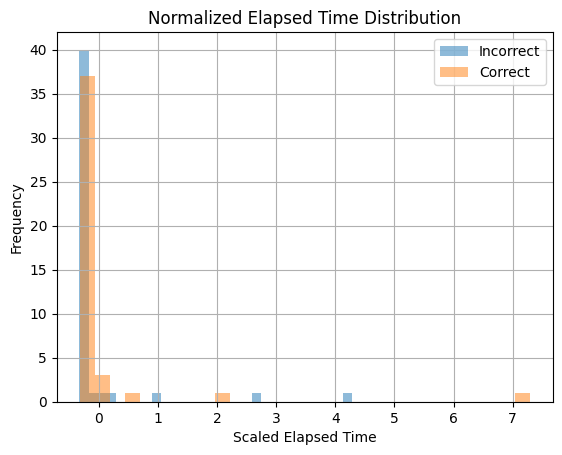

In [12]:
import matplotlib.pyplot as plt

plt.figure()

# Incorrect
session_features[session_features['target']==0]['elapsed_time'].hist(
    bins=30, alpha=0.5, label='Incorrect'
)

# Correct
session_features[session_features['target']==1]['elapsed_time'].hist(
    bins=30, alpha=0.5, label='Correct'
)

plt.title('Normalized Elapsed Time Distribution')
plt.xlabel('Scaled Elapsed Time')
plt.ylabel('Frequency')
plt.legend()
plt.show()

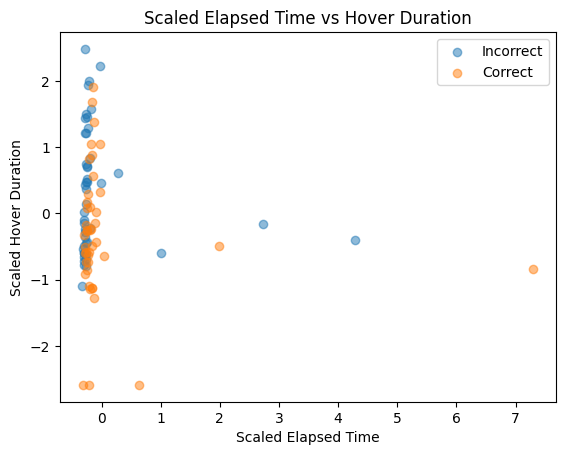

In [13]:
plt.figure()

# Incorrect
plt.scatter(
    session_features[session_features['target']==0]['elapsed_time'],
    session_features[session_features['target']==0]['hover_duration'],
    alpha=0.5,
    label='Incorrect'
)

# Correct
plt.scatter(
    session_features[session_features['target']==1]['elapsed_time'],
    session_features[session_features['target']==1]['hover_duration'],
    alpha=0.5,
    label='Correct'
)

plt.title('Scaled Elapsed Time vs Hover Duration')
plt.xlabel('Scaled Elapsed Time')
plt.ylabel('Scaled Hover Duration')
plt.legend()
plt.show()

array([[<Axes: title={'center': 'session_id'}>,
        <Axes: title={'center': 'elapsed_time'}>,
        <Axes: title={'center': 'event_name'}>],
       [<Axes: title={'center': 'hover_duration'}>,
        <Axes: title={'center': 'room_coor_x'}>,
        <Axes: title={'center': 'room_coor_y'}>],
       [<Axes: title={'center': 'event_diversity'}>,
        <Axes: title={'center': 'max_level'}>,
        <Axes: title={'center': 'total_hover'}>],
       [<Axes: title={'center': 'room_variety'}>,
        <Axes: title={'center': 'actions_per_second'}>,
        <Axes: title={'center': 'target'}>]], dtype=object)

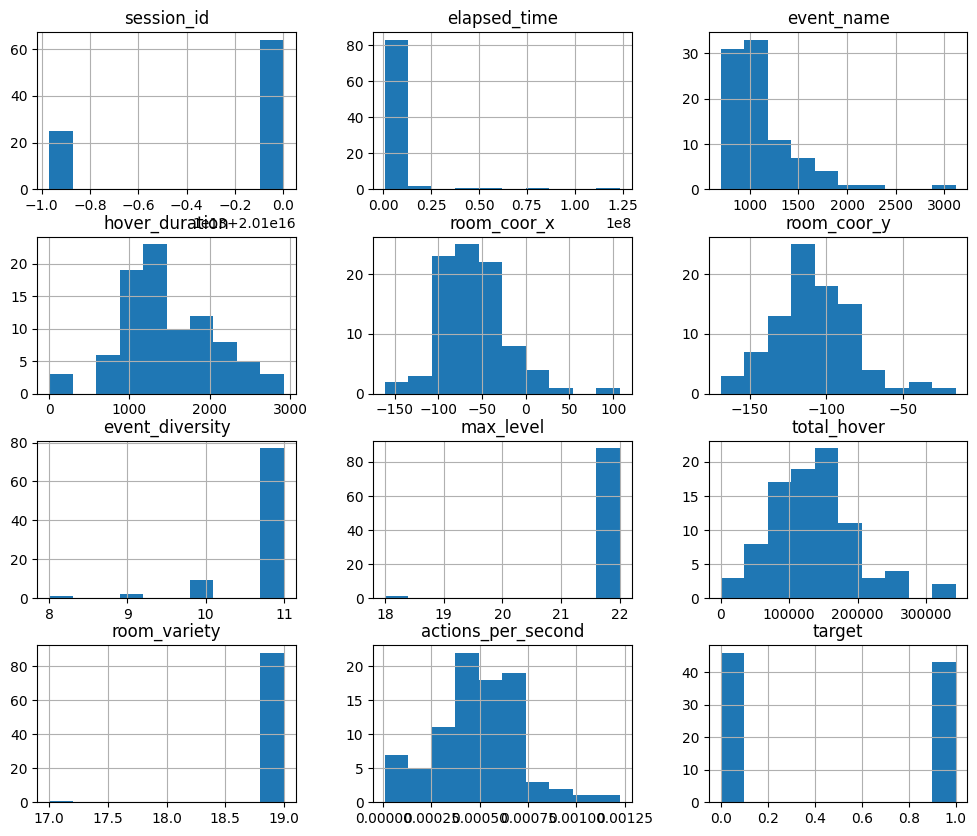

In [55]:
session_features.hist(figsize=(12,10))

In [65]:
##Data Preparation

from sklearn.model_selection import train_test_split

X = session_features[['elapsed_time', 'hover_duration', 'total_hover']]
y = session_features['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [66]:
##Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_score = log_model.score(X_test, y_test)
log_score

0.8333333333333334

In [67]:
##Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_score = dt_model.score(X_test, y_test)
dt_score

0.6666666666666666

In [68]:
##Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_score = rf_model.score(X_test, y_test)
rf_score

0.7777777777777778

<Axes: >

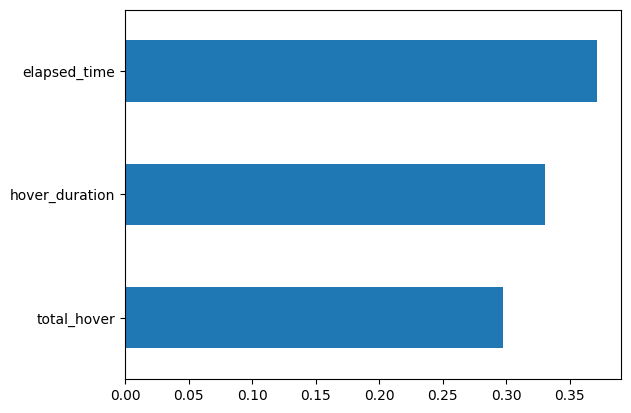

In [69]:
##feature importance of tree model

import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

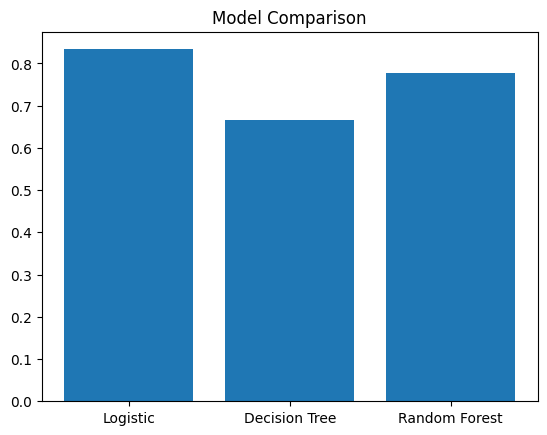

In [70]:
import matplotlib.pyplot as plt

models = ['Logistic', 'Decision Tree', 'Random Forest']
scores = [log_score, dt_score, rf_score]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.show()